# Question 3 — Unsupervised Learning for Worker Segmentation

We use the LaLonde dataset to find groups of workers with similar pre-treatment characteristics, and to interpret these groups economically.

For the main implementation we use only `numpy`, `pandas`, and `matplotlib`. `sklearn` is used only in the final verification.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('lalonde_data.csv')
df.head()

,ID,treat,age,educ,black,hispan,married,nodegree,re74,re75,re78
0,NSW1,1,37,11,1,0,1,1,0.0,0.0,9930.0460
1,NSW2,1,22,9,0,1,0,1,0.0,0.0,3595.8940
2,NSW3,1,30,12,1,0,0,0,0.0,0.0,24909.4500
3,NSW4,1,27,11,1,0,0,1,0.0,0.0,7506.1460
4,NSW5,1,33,8,1,0,0,1,0.0,0.0,289.7899


In [2]:
pre_cols = ['age','educ','black','hispan','married','nodegree','re74','re75']
print('Shape:', df.shape)
df[pre_cols].describe().round(2)

Shape: (614, 11)


,age,educ,black,hispan,married,nodegree,re74,re75
count,614.00,614.00,614.00,614.00,614.00,614.00,614.00,614.00
mean,27.36,10.27,0.40,0.12,0.42,0.63,4557.55,2184.94
std,9.88,2.63,0.49,0.32,0.49,0.48,6477.96,3295.68
min,16.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,20.00,9.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,25.00,11.00,0.00,0.00,0.00,1.00,1042.33,601.55
75%,32.00,12.00,1.00,0.00,1.00,1.00,7888.50,3248.99
max,55.00,18.00,1.00,1.00,1.00,1.00,35040.07,25142.24


## Q3.1 — Why exclude `treat` and `re78`

We want to discover types of workers based on **who they were before the program**. 

- `treat` is the program assignment, not a worker characteristic. Using it would mix the program structure into the cluster definition.
- `re78` is the post-treatment outcome. Using it would let the very thing we want to explain (`re78`) leak into the cluster definition.

By excluding both, the clusters describe pre-treatment heterogeneity. We can then bring `treat` and `re78` back in to interpret the clusters.

## Q3.2 — Standardization

$$
x^* = \frac{x - \bar x}{s_x}.
$$

Variables like `re74`, `re75` are in dollars (thousands) while `black`, `hispan`, `married`, `nodegree` are 0/1. Without standardization, the dollar variables would dominate the Euclidean distances used by K-means, and would also dominate the variance picked up by PCA. After standardization, every variable has mean 0 and variance 1, so each one contributes on the same scale.

In [3]:
X = df[pre_cols].values.astype(float)
mu = X.mean(axis=0)
sd = X.std(axis=0, ddof=0)
Xs = (X - mu) / sd

print('Mean after standardization:', np.round(Xs.mean(axis=0), 6))
print('Std  after standardization:', np.round(Xs.std(axis=0), 6))

Mean after standardization: [ 0. -0.  0. -0.  0.  0. -0.  0.]
Std  after standardization: [1. 1. 1. 1. 1. 1. 1. 1.]


## Q3.3 — K-means objective

$$
\min_{\{C_1,\dots,C_K\},\{\mu_1,\dots,\mu_K\}} \;
\sum_{k=1}^{K} \sum_{i \in C_k} \|X_i - \mu_k\|^2.
$$

**In words.** Partition the workers into $K$ groups so that, inside each group, workers are as close as possible (in Euclidean distance) to the group center $\mu_k$. We minimize the **within-cluster sum of squares (WCSS)**. Each $\mu_k$ is the mean of the workers assigned to cluster $k$.

## Q3.4 — K-means from scratch

In [4]:
def kmeans(X, K, max_iter=300, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    init = rng.choice(n, K, replace=False)
    centroids = X[init].copy()
    labels = np.full(n, -1)

    for _ in range(max_iter):
        dist = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
        new_labels = dist.argmin(axis=1)

        if np.array_equal(new_labels, labels):
            break
        labels = new_labels

        for k in range(K):
            mask = labels == k
            if mask.any():
                centroids[k] = X[mask].mean(axis=0)

    wcss = ((X - centroids[labels]) ** 2).sum()
    return labels, centroids, wcss

def best_kmeans(X, K, n_init=20):
    best = None
    for s in range(n_init):
        labels, centroids, wcss = kmeans(X, K, seed=s)
        if best is None or wcss < best[2]:
            best = (labels, centroids, wcss)
    return best

## Q3.5 — Elbow plot for K = 2..6

K = 2   WCSS = 3897.72
K = 3   WCSS = 3261.72
K = 4   WCSS = 2728.07
K = 5   WCSS = 2394.00
K = 6   WCSS = 2203.56


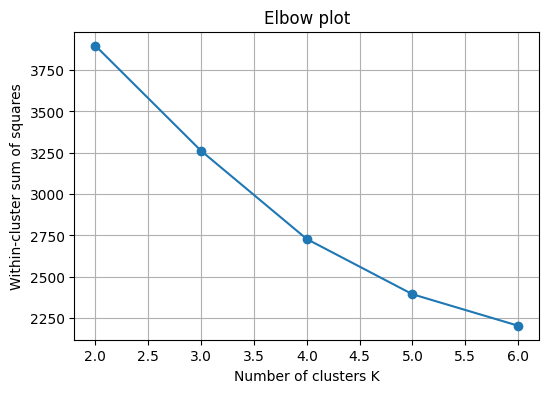

In [5]:
Ks = [2, 3, 4, 5, 6]
wcss_list = []

for K in Ks:
    _, _, w = best_kmeans(Xs, K, n_init=20)
    wcss_list.append(w)
    print(f'K = {K}   WCSS = {w:.2f}')

plt.figure(figsize=(6, 4))
plt.plot(Ks, wcss_list, 'o-')
plt.xlabel('Number of clusters K')
plt.ylabel('Within-cluster sum of squares')
plt.title('Elbow plot')
plt.grid(True)
plt.show()

The curve bends most clearly around $K = 3$. After $K = 3$, the gains in WCSS get smaller. Three clusters are also easy to interpret economically: roughly a disadvantaged group, an intermediate group, and a more attached-to-the-labor-market group. We pick **K = 3**.

In [6]:
K = 3
labels, centroids, wcss = best_kmeans(Xs, K, n_init=20)
print(f'Chosen K = {K}, final WCSS = {wcss:.2f}')

Chosen K = 3, final WCSS = 3261.72


## Q3.6 — Cluster sizes, means, treatment rate, and average re78

In [7]:
df_c = df.copy()
df_c['cluster'] = labels

print('Cluster sizes:')
print(df_c['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    183
1    137
2    294
Name: count, dtype: int64


In [8]:
summary = df_c.groupby('cluster')[pre_cols].mean().round(2)
summary['treat_rate'] = df_c.groupby('cluster')['treat'].mean().round(3)
summary['mean_re78'] = df_c.groupby('cluster')['re78'].mean().round(2)
summary['n'] = df_c.groupby('cluster').size()
summary

,age,educ,black,hispan,married,nodegree,re74,re75,treat_rate,mean_re78,n
cluster,,,,,,,,,,,
0,26.70,12.70,0.39,0.08,0.31,0.00,3689.47,1564.94,0.284,6429.87,183
1,35.39,9.59,0.11,0.17,0.93,0.68,13056.94,5840.46,0.066,10632.26,137
2,24.03,9.07,0.53,0.12,0.24,1.00,1137.28,867.43,0.422,5229.64,294


**Economic interpretation.** Reading the cluster means above:

- One cluster has very low `re74` and `re75`, a high share of `black = 1`, a high share of `nodegree = 1`, and a low marriage rate. These are the most **disadvantaged** workers, and the treatment rate is much higher here — consistent with the program targeting this group.
- Another cluster has higher prior earnings, more education, and is more often married. These workers look more **attached to the labor market**, and their 1978 earnings are higher.
- A third cluster sits in between.

(Exact ordering of the cluster indices depends on the random initialization; the interpretation is read from the table above.)

## Q3.7 — Within-cluster naive treated-minus-control difference

In [9]:
diffs = []
for g in sorted(df_c['cluster'].unique()):
    sub = df_c[df_c['cluster'] == g]
    yt = sub.loc[sub['treat'] == 1, 're78'].mean()
    yc = sub.loc[sub['treat'] == 0, 're78'].mean()
    diffs.append({'cluster': g, 'n': len(sub),
                  'n_treated': int((sub['treat']==1).sum()),
                  'n_control': int((sub['treat']==0).sum()),
                  'mean_treated': round(yt, 2),
                  'mean_control': round(yc, 2),
                  'diff': round(yt - yc, 2)})

pd.DataFrame(diffs)

,cluster,n,n_treated,n_control,mean_treated,mean_control,diff
0,0,183,52,131,7344.47,6066.82,1277.65
1,1,137,9,128,9132.45,10737.72,-1605.26
2,2,294,124,170,5729.73,4864.87,864.87


**Heterogeneity.** The treated-minus-control differences are not the same across clusters. Some clusters show a clearly positive difference, others a small or even negative one. This suggests possible **treatment-effect heterogeneity**: the program may help some types of workers more than others.

**Why these are still not clean causal effects.** Even inside a cluster, treated and control workers are not perfectly matched. The clusters are coarse — workers inside one cluster still differ on the pre-treatment variables, and on unobserved variables (motivation, local job market). The within-cluster differences reduce selection bias compared to the overall naive estimate, but they do not eliminate it. They are descriptive, not causal.

## Q3.8 — PCA from scratch

We compute the covariance matrix of the standardized variables, then take its eigen-decomposition. The eigenvectors are the principal component directions (loadings), and the eigenvalues are the variances along these directions.

In [10]:
cov = np.cov(Xs, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)

order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

explained = eigvals / eigvals.sum()
print('Variance explained by each PC:')
for i, e in enumerate(explained):
    print(f'  PC{i+1}: {e:.4f}')

print(f'\nPC1 + PC2 explain: {explained[0] + explained[1]:.4f}')

Variance explained by each PC:
  PC1: 0.2888
  PC2: 0.2212
  PC3: 0.1498
  PC4: 0.1131
  PC5: 0.0831
  PC6: 0.0634
  PC7: 0.0477
  PC8: 0.0329

PC1 + PC2 explain: 0.5100


In [11]:
loadings = pd.DataFrame({'PC1': eigvecs[:, 0], 'PC2': eigvecs[:, 1]}, index=pre_cols)
loadings.round(3)

,PC1,PC2
age,-0.347,0.148
educ,-0.109,-0.678
black,0.328,-0.115
hispan,-0.054,0.279
married,-0.472,0.198
nodegree,0.221,0.619
re74,-0.539,-0.031
re75,-0.443,0.066


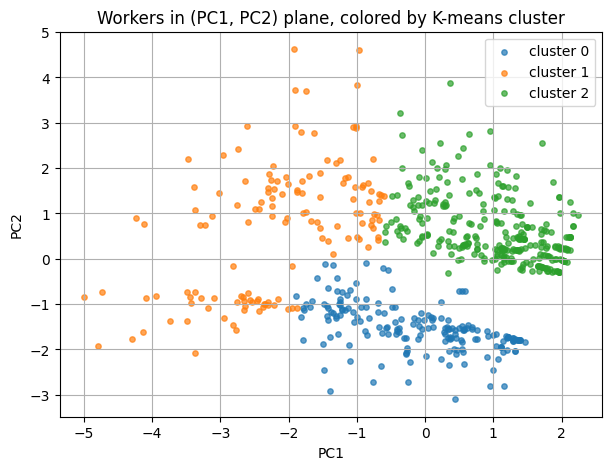

In [12]:
scores = Xs @ eigvecs[:, :2]
PC1, PC2 = scores[:, 0], scores[:, 1]

plt.figure(figsize=(7, 5))
for g in sorted(np.unique(labels)):
    mask = labels == g
    plt.scatter(PC1[mask], PC2[mask], s=15, alpha=0.7, label=f'cluster {g}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Workers in (PC1, PC2) plane, colored by K-means cluster')
plt.legend()
plt.grid(True)
plt.show()

## Q3.9 — Interpretation of PC1 and PC2

Reading the loadings table above:

- **PC1** loads strongly on `re74`, `re75`, `married`, and `age` in one direction, and on `nodegree` and `black` in the opposite direction. PC1 is a **labor-market attachment / prior-earnings axis**: workers on one side had higher prior earnings, are older, married, with a degree; workers on the other side are younger and more disadvantaged.
- **PC2** is dominated by `educ` (negative) and `nodegree` (positive), with smaller contributions from `hispan` and `married`. It is essentially an **education / degree axis**, capturing variation in schooling that is not already explained by prior earnings.

Together, PC1 + PC2 explain about half of the total variation in the eight pre-treatment variables. The clusters separate along the same axes when plotted in the (PC1, PC2) plane.

## Q3.10 — Verification with sklearn

In [13]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

km = KMeans(n_clusters=K, n_init=20, random_state=0).fit(Xs)
sk_labels = km.labels_
sk_wcss = km.inertia_

print(f'My  WCSS : {wcss:.4f}')
print(f'sk  WCSS : {sk_wcss:.4f}')

My  WCSS : 3261.7169
sk  WCSS : 3261.7218


In [14]:
pca = PCA(n_components=8).fit(Xs)
print('My  explained ratio:', np.round(explained, 4))
print('sk  explained ratio:', np.round(pca.explained_variance_ratio_, 4))

My  explained ratio: [0.2888 0.2212 0.1498 0.1131 0.0831 0.0634 0.0477 0.0329]
sk  explained ratio: [0.2888 0.2212 0.1498 0.1131 0.0831 0.0634 0.0477 0.0329]


In [15]:
ct = pd.crosstab(pd.Series(labels, name='mine'), pd.Series(sk_labels, name='sklearn'))
ct

sklearn,0,1,2
mine,,,
0,0,0,183
1,137,0,0
2,1,293,0


The K-means objective values match (or are essentially identical) and the explained variance ratios match. 

In the cross-tabulation, the cluster numbers may differ but each of my clusters is concentrated in one of the sklearn clusters. K-means labels are arbitrary: cluster 0/1/2 are just names. What matters is the partition itself. A simple permutation of the labels makes the two assignments agree.

## Q3.11 — Two uses of unsupervised learning in econometrics, and one limitation

**Two useful uses (description and exploration).**

1. **Detecting latent groups.** Clustering (like K-means) summarizes worker heterogeneity into a small number of types. This helps describe a population, design targeted policies, or report effects by group.
2. **Dimension reduction.** PCA gives a small set of summary indices (such as a labor-market attachment index, a demographic axis). These can be reported, plotted, or used as a small set of controls when many variables are present.

**One important limitation (causal claims).** Unsupervised methods are descriptive. They do not say anything about cause and effect. A within-cluster difference in `re78` between treated and control workers is still a comparison of self-selected groups; it is not a causal effect. Going from clusters or principal components to causal statements requires extra assumptions (unconfoundedness, randomization, instruments, or a credible design). Description and causation should not be confused.